In [1]:
import numpy as np
from gaussian_systems.initial_state import GaussianCVState
from gaussian_systems.systems import GaussianCVSystem, single_pole_ou_embedding
import matplotlib.pyplot as plt

In [2]:
n = 2 # system size
kappa = 1 # normalized decay rate
n_mode_state = GaussianCVState.vacuum(2)
n_mode_state.single_mode_squeeze((0.5, 0.0), 1)
base_state = n_mode_state.copy_state().single_mode_squeeze((0.5, 0.0), 2)

In [43]:
mode_frequencies = np.array([2.0*kappa,2.0*kappa])
n_mode_free_system = GaussianCVSystem.free_evolution(n, mode_frequencies)

markovian_system = n_mode_free_system.copy_system().multi_annihilation_dissipator(
    subsystem=(1,2),
    decay=kappa
)

ou_base_state, ou_base_system =  single_pole_ou_embedding(
    state=base_state,
    system=n_mode_free_system,
    subsystem=(1,2),
    coupling_types=("annihilation", "annihilation"), 
    memory_rate=0.1*kappa,
    env_freq=2.5*kappa,
    decay_rate=kappa
)

In [45]:
t_eval = np.linspace(0,100,2000)

base_solution = markovian_system.evolve_state(base_state,t_eval)
ou_solution = ou_base_system.evolve_state(ou_base_state, t_eval)

In [46]:
base_entanglement = base_solution.entanglement_time_trace((1,2))
base_purity = base_solution.purity_time_trace((1,2))

ou_entanglement = ou_solution.entanglement_time_trace((1,2))
ou_purity = ou_solution.purity_time_trace((1,2))

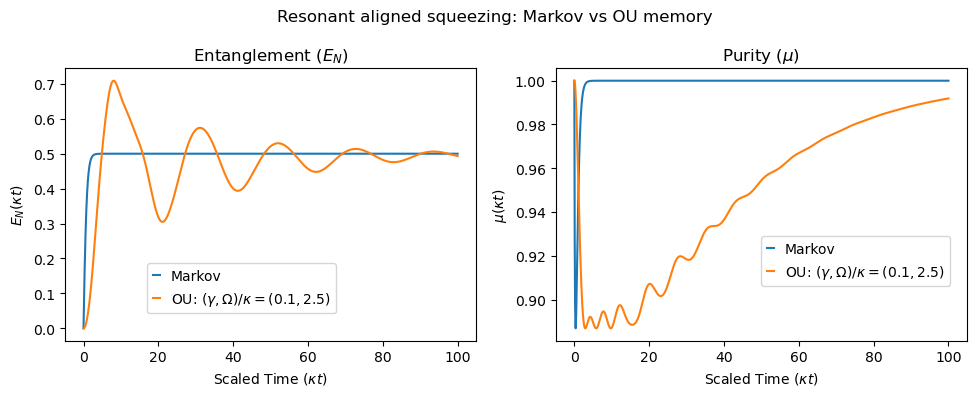

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(t_eval, base_entanglement, label="Markov")
axes[0].plot(t_eval, ou_entanglement, label=r"OU: $(\gamma,\Omega)/\kappa = (0.1,2.5)$")
axes[0].set_title(r"Entanglement ($E_N$)")
axes[0].set_ylabel(r"$E_N(\kappa t)$")
axes[1].plot(t_eval, base_purity, label="Markov")
axes[1].plot(t_eval, ou_purity, label=r"OU: $(\gamma,\Omega)/\kappa = (0.1,2.5)$")
axes[1].set_title(r"Purity ($\mu$)")
axes[1].set_ylabel(r"$\mu(\kappa t)$")
for ax in axes:
    ax.set_xlabel(r"Scaled Time $(\kappa t)$")
axes[0].legend(loc=(0.2, 0.1), handlelength=0.5)
axes[1].legend(loc=(0.5, 0.2), handlelength=0.5)
fig.suptitle("Resonant aligned squeezing: Markov vs OU memory")
plt.tight_layout()
plt.show()

In [50]:
detuned_frequencies = np.array([2.0*kappa,2.5*kappa])
detuned_system = GaussianCVSystem.free_evolution(n, detuned_frequencies)

markovian_detuned_system = detuned_system.copy_system().multi_annihilation_dissipator(
    subsystem=(1,2),
    decay=kappa
)

orthogonal_state = n_mode_state.single_mode_squeeze((0.5,np.pi),2)

ou_orthogonal_state, ou_detuned_system =  single_pole_ou_embedding(
    state=orthogonal_state,
    system=detuned_system,
    subsystem=(1,2),
    coupling_types=("annihilation", "annihilation"), 
    memory_rate=0.1*kappa,
    env_freq=2.5*kappa,
    decay_rate=kappa
)

In [51]:
t_eval = np.linspace(0,100,2000)

detuned_solution = markovian_detuned_system.evolve_state(orthogonal_state,t_eval)
ou_detuned_solution = ou_detuned_system.evolve_state(ou_orthogonal_state, t_eval)

In [52]:
detuned_entanglement = detuned_solution.entanglement_time_trace((1,2))
detuned_purity = detuned_solution.purity_time_trace((1,2))

ou_detuned_entanglement = ou_detuned_solution.entanglement_time_trace((1,2))
ou_detuned_purity = ou_detuned_solution.purity_time_trace((1,2))

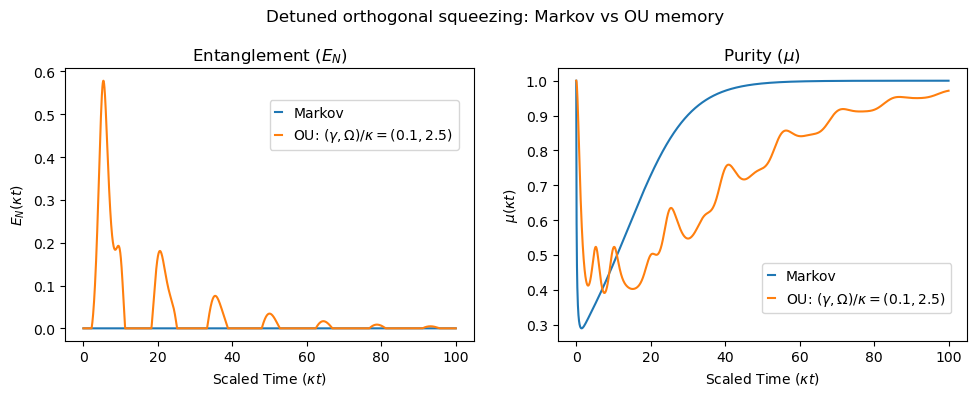

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(t_eval, detuned_entanglement, label="Markov")
axes[0].plot(t_eval, ou_detuned_entanglement, label=r"OU: $(\gamma,\Omega)/\kappa = (0.1,2.5)$")
axes[0].set_title(r"Entanglement ($E_N$)")
axes[0].set_ylabel(r"$E_N(\kappa t)$")
axes[1].plot(t_eval, detuned_purity, label="Markov")
axes[1].plot(t_eval, ou_detuned_purity, label=r"OU: $(\gamma,\Omega)/\kappa = (0.1,2.5)$")
axes[1].set_title(r"Purity ($\mu$)")
axes[1].set_ylabel(r"$\mu(\kappa t)$")
for ax in axes:
    ax.set_xlabel(r"Scaled Time $(\kappa t)$")
axes[0].legend(loc=(0.5, 0.7), handlelength=0.5)
axes[1].legend(loc=(0.5, 0.1), handlelength=0.5)
fig.suptitle("Detuned orthogonal squeezing: Markov vs OU memory")
plt.tight_layout()
plt.show()